In [5]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import xarray as xr
import pandas as pd

# =========================================================
# 0. 参数
# =========================================================
data_dir = r"E:/huawei/result"
save_dir = r"E:/huawei/result/shap_grouped_figs"
os.makedirs(save_dir, exist_ok=True)

lead_list = [1, 2, 3, 4, 5, 6]
file_template = "CNN_Transformer_{}_5year_order_fusion_shap.nc"

# 如果你明确知道变量名，可直接写，比如 "shap_values"
# 不知道就设为 None 自动识别
var_name = None

group_feature_names = ['q', 'e', 'p', 'dq_dt', 'dq_dlat', 'dq_dlon']

save_npz = os.path.join(save_dir, "grouped_shap_6vars_intermediate.npz")
save_csv = os.path.join(save_dir, "grouped_shap_6vars_time_series.csv")
save_summary_csv = os.path.join(save_dir, "grouped_shap_6vars_summary.csv")


# =========================================================
# 1. 工具函数
# =========================================================
def detect_main_var(ds, user_var_name=None):
    if user_var_name is not None:
        if user_var_name not in ds.data_vars:
            raise ValueError(f"指定变量 {user_var_name} 不在文件中，现有变量: {list(ds.data_vars)}")
        return user_var_name

    data_vars = list(ds.data_vars)
    if len(data_vars) == 1:
        return data_vars[0]

    shap_like = [v for v in data_vars if "shap" in v.lower()]
    if len(shap_like) > 0:
        return shap_like[0]

    raise ValueError(f"无法自动判断主变量，请手动指定 var_name。当前变量有: {data_vars}")


def group_30_features_to_6(arr_2d):
    """
    输入:
        arr_2d: shape = (time, 30)
    输出:
        grouped: shape = (time, 6)
    """
    arr_2d = np.asarray(arr_2d, dtype=np.float64)
    if arr_2d.ndim != 2 or arr_2d.shape[1] != 30:
        raise ValueError(f"输入必须为 (time, 30)，当前 shape={arr_2d.shape}")

    q       = np.nanmean(arr_2d[:, 0:7],   axis=1)   # 0-6
    e       = arr_2d[:, 7]                           # 7
    p       = arr_2d[:, 8]                           # 8
    dq_dt   = np.nanmean(arr_2d[:, 9:16],  axis=1)   # 9-15
    dq_dlat = np.nanmean(arr_2d[:, 16:23], axis=1)   # 16-22
    dq_dlon = np.nanmean(arr_2d[:, 23:30], axis=1)   # 23-29

    grouped = np.stack([q, e, p, dq_dt, dq_dlat, dq_dlon], axis=1)
    return grouped


# =========================================================
# 2. 逐个文件读取，先压成 (time, 6)
# =========================================================
lead_data = []

for lead in lead_list:
    nc_path = os.path.join(data_dir, file_template.format(lead))
    print(f"\n>>> 正在读取: {nc_path}")

    if not os.path.exists(nc_path):
        raise FileNotFoundError(f"文件不存在: {nc_path}")

    ds = xr.open_dataset(nc_path)
    vname = detect_main_var(ds, var_name)
    da = ds[vname]

    print(f"    使用变量: {vname}")
    print(f"    原始 dims : {da.dims}")
    print(f"    原始 shape: {da.shape}")

    if "time" not in da.dims or "feature" not in da.dims:
        raise ValueError(f"{nc_path} 中必须包含 time 和 feature 维，当前 dims={da.dims}")

    # 除 time / feature 外，其余维度全平均
    mean_dims = [d for d in da.dims if d not in ["time", "feature"]]
    print(f"    将平均这些维度: {mean_dims}")

    da_tf = da.mean(dim=mean_dims, skipna=True).transpose("time", "feature")
    arr_30 = da_tf.values
    arr_6 = group_30_features_to_6(arr_30)

    # time 坐标
    try:
        time_vals = np.asarray(da_tf["time"].values)
    except Exception:
        time_vals = None

    print(f"    聚合后 shape: {arr_6.shape} -> (time, 6)")

    lead_data.append({
        "lead": lead,
        "time": time_vals,
        "arr6": arr_6
    })

    ds.close()


# =========================================================
# 3. 对齐 6 个 lead
#    优先按共同 time 交集；
#    如果交集失败，则裁到最短长度
# =========================================================
use_time_intersection = True
common_time = None

for item in lead_data:
    if item["time"] is None:
        use_time_intersection = False
        break

    try:
        idx = pd.Index(item["time"])
    except Exception:
        use_time_intersection = False
        break

    if common_time is None:
        common_time = idx
    else:
        common_time = common_time.intersection(idx)

aligned_list = []
final_time = None

if use_time_intersection and common_time is not None and len(common_time) > 0:
    print(f"\n>>> 使用 time 交集对齐，交集长度 = {len(common_time)}")
    for item in lead_data:
        idx = pd.Index(item["time"])
        loc = idx.get_indexer(common_time)
        if np.any(loc < 0):
            use_time_intersection = False
            print(">>> 某些文件无法完全按交集索引，改用最短长度裁剪。")
            break
        aligned_list.append(item["arr6"][loc, :])

    if use_time_intersection:
        final_time = np.array(common_time.astype(str))

if (not use_time_intersection) or (len(aligned_list) == 0):
    min_len = min(item["arr6"].shape[0] for item in lead_data)
    print(f"\n>>> 改用最短长度裁剪对齐，min_len = {min_len}")

    for item in lead_data:
        aligned_list.append(item["arr6"][:min_len, :])

    # 尝试保留第一份数据的前 min_len 个 time
    if lead_data[0]["time"] is not None and len(lead_data[0]["time"]) >= min_len:
        final_time = np.asarray(lead_data[0]["time"][:min_len]).astype(str)
    else:
        final_time = np.arange(min_len).astype(str)


# =========================================================
# 4. lead 平均 -> (time, 6)
# =========================================================
all_leads_grouped = np.stack(aligned_list, axis=0)   # (lead, time, 6)
grouped_shap = np.nanmean(all_leads_grouped, axis=0) # (time, 6)

print("\n>>> 最终 grouped_shap shape:", grouped_shap.shape)

# 全局重要性
global_importance = np.nanmean(np.abs(grouped_shap), axis=0)
total_importance = np.nansum(global_importance)

if total_importance == 0:
    weights = np.zeros_like(global_importance)
else:
    weights = global_importance / total_importance * 100.0

# =========================================================
# 5. 保存中间结果
# =========================================================
# 保存 npz，供后续单独绘图读取
np.savez(
    save_npz,
    grouped_shap=grouped_shap,
    weights=weights,
    feature_names=np.array(group_feature_names, dtype="U"),
    time=np.array(final_time, dtype="U")
)

# 保存 time-feature 表
df_ts = pd.DataFrame(grouped_shap, columns=group_feature_names)
df_ts.insert(0, "time", final_time)
df_ts.to_csv(save_csv, index=False, encoding="utf-8-sig")

# 保存 summary 表
df_summary = pd.DataFrame({
    "feature": group_feature_names,
    "mean_abs_shap": global_importance,
    "weight_percent": weights
}).sort_values("weight_percent", ascending=False)
df_summary.to_csv(save_summary_csv, index=False, encoding="utf-8-sig")

print(f">>> 已保存中间结果: {save_npz}")
print(f">>> 已保存时间序列表: {save_csv}")
print(f">>> 已保存汇总表: {save_summary_csv}")

print("\n>>> 最终权重(%)：")
for n, w in zip(group_feature_names, weights):
    print(f"{n}: {w:.2f}%")


>>> 正在读取: E:/huawei/result\CNN_Transformer_1_5year_order_fusion_shap.nc
    使用变量: shap_values
    原始 dims : ('time', 'feature', 'latx', 'lonx', 'n')
    原始 shape: (8760, 30, 23, 33, 21)
    将平均这些维度: ['latx', 'lonx', 'n']
    聚合后 shape: (8760, 6) -> (time, 6)

>>> 正在读取: E:/huawei/result\CNN_Transformer_2_5year_order_fusion_shap.nc
    使用变量: shap_values
    原始 dims : ('time', 'feature', 'latx', 'lonx', 'n')
    原始 shape: (8760, 30, 23, 33, 21)
    将平均这些维度: ['latx', 'lonx', 'n']
    聚合后 shape: (8760, 6) -> (time, 6)

>>> 正在读取: E:/huawei/result\CNN_Transformer_3_5year_order_fusion_shap.nc
    使用变量: shap_values
    原始 dims : ('time', 'feature', 'latx', 'lonx', 'n')
    原始 shape: (8760, 30, 23, 33, 21)
    将平均这些维度: ['latx', 'lonx', 'n']
    聚合后 shape: (8760, 6) -> (time, 6)

>>> 正在读取: E:/huawei/result\CNN_Transformer_4_5year_order_fusion_shap.nc
    使用变量: shap_values
    原始 dims : ('time', 'feature', 'latx', 'lonx', 'n')
    原始 shape: (8759, 30, 23, 33, 21)
    将平均这些维度: ['latx', 'lonx', 'n'

>>> 读取到的特征和权重：
q: 20.82%
e: 20.58%
p: 10.76%
dq_dt: 14.81%
dq_dlat: 16.71%
dq_dlon: 16.33%


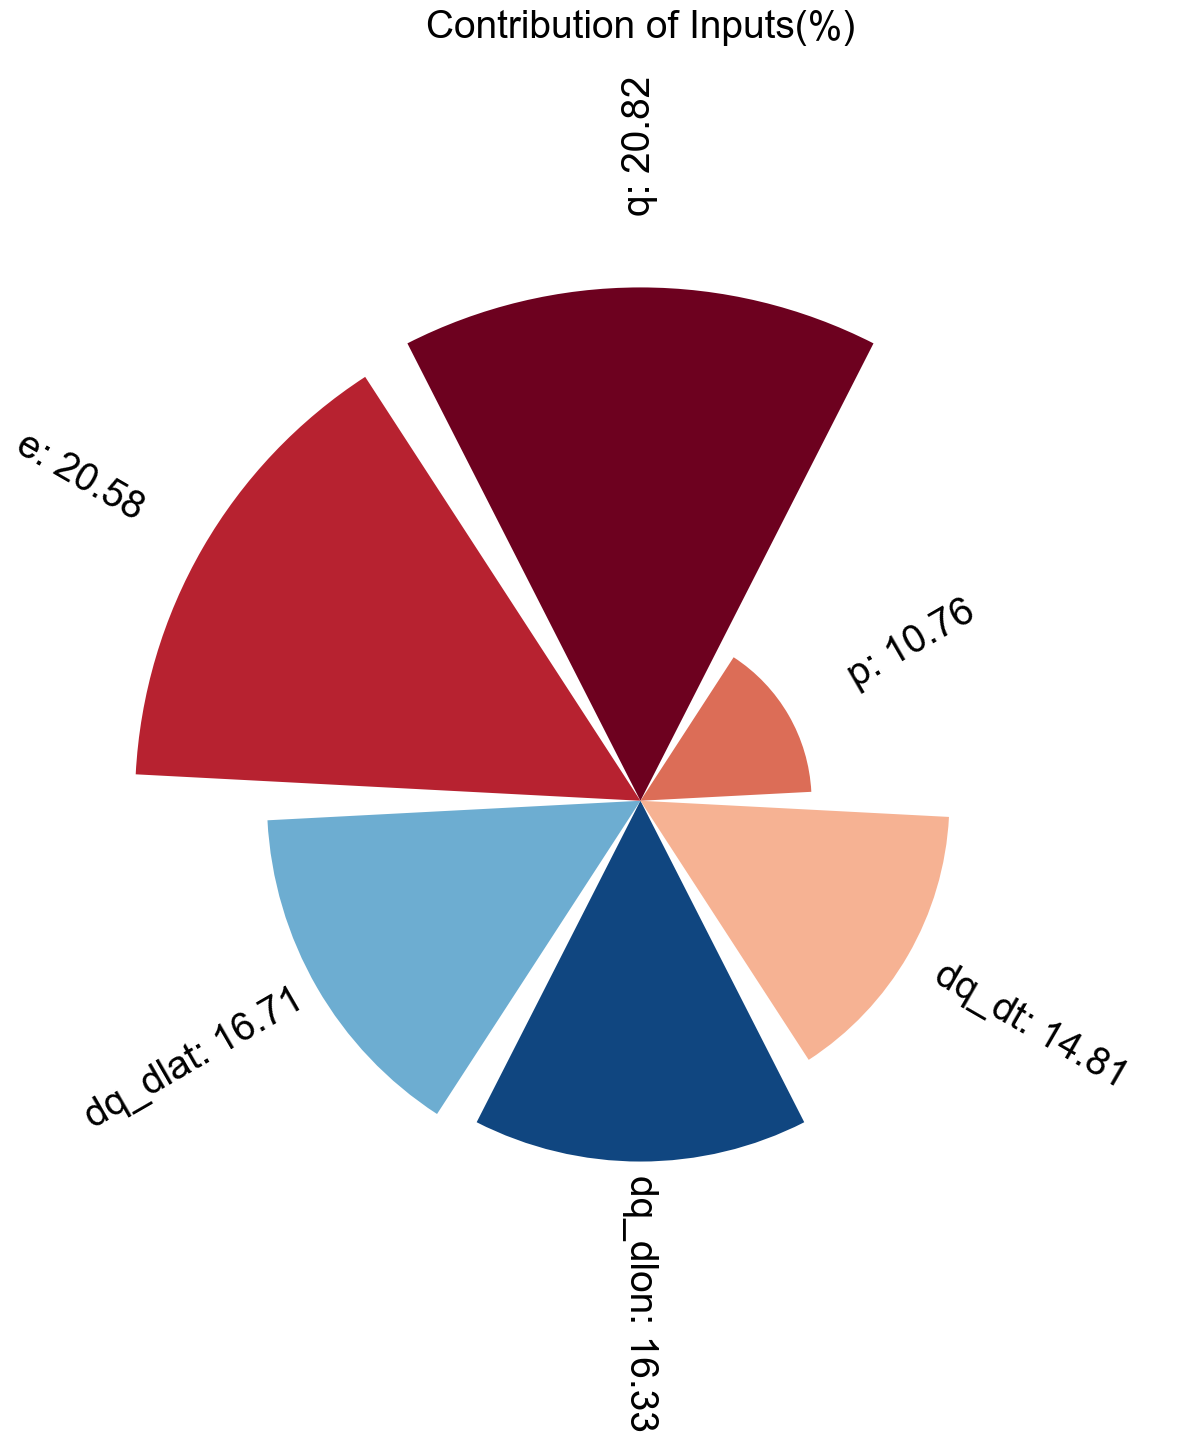

>>> 已保存花瓣图: E:/huawei/result/shap_grouped_figs\Grouped_SHAP_Petal.png


In [9]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 0. 参数
# =========================================================
save_dir = r"E:/huawei/result/shap_grouped_figs"
load_npz = os.path.join(save_dir, "grouped_shap_6vars_intermediate.npz")
save_petal = os.path.join(save_dir, "Grouped_SHAP_Petal.png")

labelsize = 28
title = "Contribution of Inputs(%)"

# 6 个变量的颜色（从高贡献暖色到低贡献冷色）
my_colors = [
    "#6D011F", "#B72230", "#DC6D57",
    "#F6B293", "#6DADD1", "#104680"
]


# =========================================================
# 1. 读取中间结果
# =========================================================
if not os.path.exists(load_npz):
    raise FileNotFoundError(f"中间结果不存在: {load_npz}\n请先运行第一个代码框。")

data = np.load(load_npz, allow_pickle=True)
weights = data["weights"]
feature_names_arr = data["feature_names"]

print(">>> 读取到的特征和权重：")
for n, w in zip(feature_names_arr, weights):
    print(f"{n}: {w:.2f}%")


# =========================================================
# 2. 花瓣图函数（按你之前认可的风格）
# =========================================================
def Auto_petal_plot(v, labels, selfcolor=None, labelsize=20, title=' ',
                    ifsave='no', savename=None):
    import numpy as np
    import matplotlib.pyplot as plt

    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['axes.unicode_minus'] = False

    if selfcolor is not None and isinstance(selfcolor, str):
        try:
            selfcolor = getattr(plt.cm, selfcolor)
        except AttributeError:
            selfcolor = plt.cm.viridis
    elif selfcolor is None:
        selfcolor = plt.cm.viridis

    v_array = np.array(v, dtype=float)
    labels_array = np.array(labels)

    if len(v_array) == 0:
        fig, ax = plt.subplots(subplot_kw={'polar': True}, figsize=(12, 12), facecolor='white')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, y=1.05, fontsize=labelsize)
        plt.show()
        if ifsave == 'yes' and savename:
            fig.savefig(savename, dpi=300, bbox_inches='tight', facecolor='white')
        return

    # 按贡献度从大到小排序
    sorted_indices = np.argsort(v_array)[::-1]
    labels_sorted = labels_array[sorted_indices]
    v_values_sorted = v_array[sorted_indices]

    N = len(v_values_sorted)
    theta = np.linspace(0.0, 2 * np.pi, N, endpoint=False)

    min_val_orig = np.min(v_values_sorted)
    max_val_orig = np.max(v_values_sorted)
    range_val_orig = max_val_orig - min_val_orig

    # 高度缩放（保持你之前的视觉风格）
    scaled_min_display = 0.5
    scaled_max_display = 1.5
    if range_val_orig < 1e-12:
        heights_for_plot = np.full_like(v_values_sorted, scaled_min_display, dtype=float)
    else:
        heights_for_plot = (
            (v_values_sorted - min_val_orig) / range_val_orig
            * (scaled_max_display - scaled_min_display)
            + scaled_min_display
        )

    gap = 0.10
    width = (2 * np.pi / N) * (1 - gap)

    fig, ax = plt.subplots(subplot_kw={'polar': True}, figsize=(14, 14), facecolor='white')
    ax.spines['polar'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    if not isinstance(selfcolor, list):
        colors_to_use = selfcolor(np.linspace(0.2, 0.8, N))
    else:
        colors_to_use = np.array(selfcolor)[sorted_indices]

    ax.bar(
        theta,
        heights_for_plot,
        width=width,
        bottom=0.0,
        color=colors_to_use,
        edgecolor='none'
    )

    max_plot_height_val = np.max(heights_for_plot) if N > 0 else 1.0
    label_radial_offset = max_plot_height_val * 0.25 + ((labelsize - 20) * 0.005)

    for i in range(N):
        bar_plotted_height = heights_for_plot[i]
        original_value_for_label = v_values_sorted[i]
        current_label_text = labels_sorted[i]
        angle_rad_for_position = theta[i]
        r_label_position = bar_plotted_height + label_radial_offset

        angle_deg_of_petal = np.degrees(angle_rad_for_position)
        text_rotation_tangential = angle_deg_of_petal + 90.0
        final_text_rotation = text_rotation_tangential
        normalized_angle = final_text_rotation % 360

        if 90 < normalized_angle < 270:
            final_text_rotation += 180.0

        ax.text(
            angle_rad_for_position, r_label_position,
            f'{current_label_text}: {original_value_for_label:.2f}',
            ha='center', va='center',
            fontsize=labelsize,
            rotation=final_text_rotation,
            rotation_mode='anchor'
        )

    ax.set_theta_zero_location('N')
    ax.set_title(title, y=1.2, fontsize=labelsize)
    plt.show()

    if ifsave == 'yes' and savename is not None:
        fig.savefig(savename, dpi=300, bbox_inches='tight', facecolor='white')


# =========================================================
# 3. 绘图
# =========================================================
Auto_petal_plot(
    v=weights,
    labels=feature_names_arr,
    selfcolor=my_colors,
    labelsize=labelsize,
    title=title,
    ifsave='yes',
    savename=save_petal
)

print(f">>> 已保存花瓣图: {save_petal}")